# 2. Visualización Avanzada y Análisis de Tendencias

En este notebook profundizamos en los datos obtenidos de la API de GitHub. Exploraremos:

- **Tendencias temporales:** ¿Cómo evoluciona la actividad (estrellas, forks, issues) en el tiempo?
- **Distribuciones:** ¿Qué lenguajes predominan? ¿Cómo se distribuyen las estrellas?
- **Correlaciones:** ¿Hay relación entre estrellas, forks, issues y tamaño del repositorio?
- **Análisis de texto:** ¿Qué palabras clave aparecen en las descripciones de repositorios populares?

No utilizaremos machine learning, solo análisis exploratorio avanzado y visualizaciones.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
from collections import Counter
import re

# Para nube de palabras (opcional, instalar con: pip install wordcloud)
# from wordcloud import WordCloud

# Configurar visualizaciones
%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


In [6]:
# Cargar datos guardados del notebook anterior (formato CSV)
import os
import pandas as pd

data_path = '../data/github_repos.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Datos cargados: {len(df)} repositorios")
    print(f"Columnas disponibles: {df.columns.tolist()}")
    df.head()
else:
    print("❌ Archivo no encontrado. Ejecuta el notebook 01 primero.")
    df = None  # Para evitar errores

✅ Datos cargados: 500 repositorios
Columnas disponibles: ['name', 'full_name', 'description', 'language', 'stargazers_count', 'watchers_count', 'forks_count', 'open_issues_count', 'created_at', 'updated_at', 'pushed_at', 'html_url', 'age_days']


## 1. Limpieza y preparación de datos
- Convertir fechas a datetime.
- Extraer información adicional de las descripciones (ej. palabras clave).
- Crear columnas derivadas (ej. edad del repositorio).

In [10]:

# Convertir fechas a datetime con zona horaria UTC
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['updated_at'] = pd.to_datetime(df['updated_at'], utc=True)
df['pushed_at'] = pd.to_datetime(df['pushed_at'], utc=True)

# Obtener la fecha/hora actual en UTC
now = pd.Timestamp.now(tz='UTC')

# Calcular edad del repositorio (días desde creación)
df['age_days'] = (now - df['created_at']).dt.days

# Calcular ratio de estrellas por día (popularidad)
df['stars_per_day'] = df['stargazers_count'] / (df['age_days'] + 1)

# Extraer palabras clave de la descripción (si no está vacía)
def extract_keywords(desc):
    if pd.isna(desc) or desc == '':
        return []

    # Limpiar y tokenizar
    words = re.findall(r'\b[a-zA-Z]{3,}\b', desc.lower())

    # Palabras que no queremos considerar como keywords
    stopwords = [
        'for', 'with', 'from', 'this', 'that',
        'are', 'you', 'not', 'and', 'the',
        'but', 'can', 'has', 'was', 'all'
    ]

    words = [w for w in words if w not in stopwords]

    return words

# Aplicar extracción de keywords
df['keywords'] = df['description'].apply(extract_keywords)

# Confirmar que los datos fueron preparados correctamente
print("✅ Datos preparados correctamente.")

# Mostrar resultados
df[['name', 'stargazers_count', 'age_days', 'stars_per_day', 'keywords']].head()



✅ Datos preparados correctamente.


,name,stargazers_count,age_days,stars_per_day,keywords
0,build-your-own-x,532733,3003,177.341212,"[master, programming, recreating, your, favori..."
1,awesome,490367,4401,111.396411,"[awesome, lists, about, kinds, interesting, to..."
2,public-apis,453312,3782,119.828707,"[collective, list, free, apis]"
3,freeCodeCamp,453120,4235,106.968839,"[freecodecamp, org, open, source, codebase, cu..."
4,free-programming-books,393271,4674,84.122139,"[books, freely, available, programming, books]"


## 2. Distribuciones de variables clave
- Lenguajes más populares.
- Distribución de estrellas, forks y issues.
- Tamaño de repositorios (si disponible).

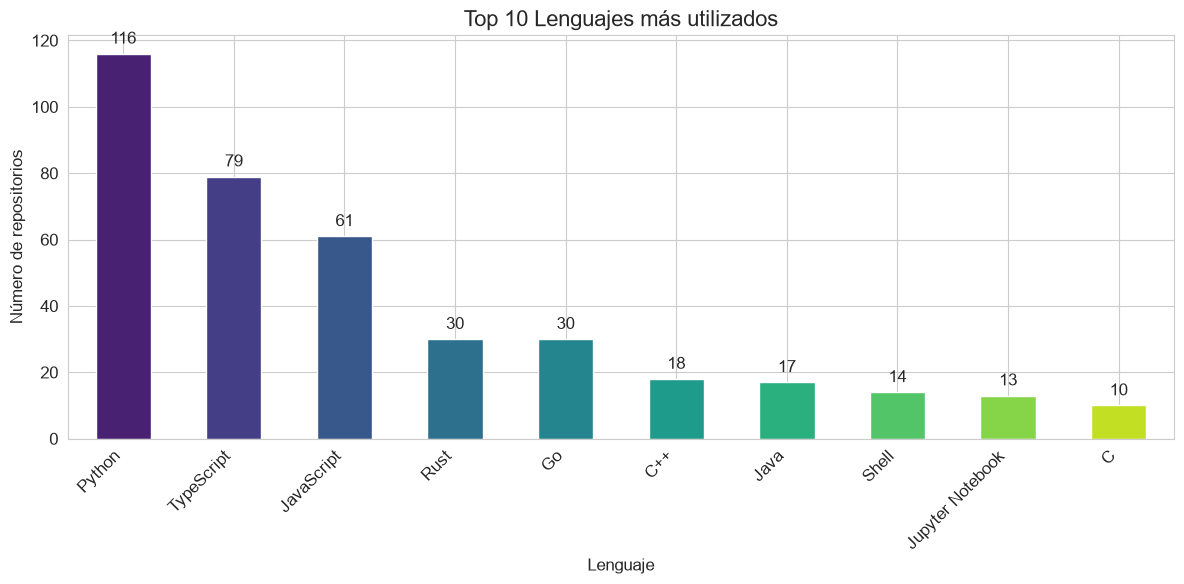

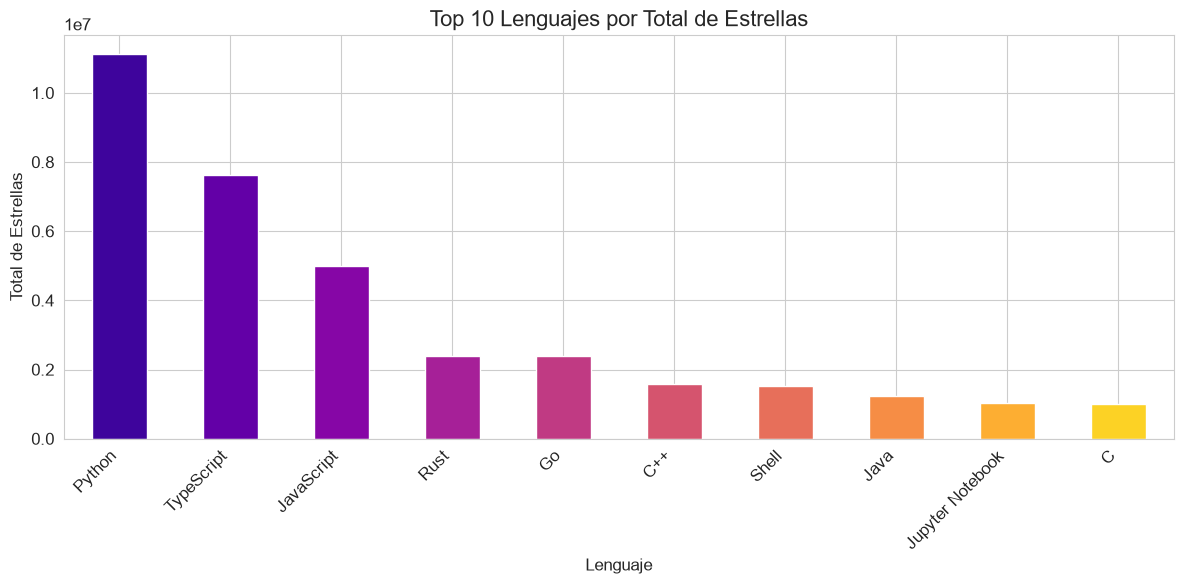

In [11]:
# Top lenguajes (por número de repositorios)
lang_counts = df['language'].value_counts().head(10)

plt.figure(figsize=(12, 6))
lang_counts.plot(kind='bar', color=sns.color_palette('viridis', 10))
plt.title('Top 10 Lenguajes más utilizados', fontsize=16)
plt.xlabel('Lenguaje')
plt.ylabel('Número de repositorios')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(lang_counts):
    plt.text(i, v + 2, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Top lenguajes por estrellas totales
lang_stars = df.groupby('language')['stargazers_count'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
lang_stars.plot(kind='bar', color=sns.color_palette('plasma', 10))
plt.title('Top 10 Lenguajes por Total de Estrellas', fontsize=16)
plt.xlabel('Lenguaje')
plt.ylabel('Total de Estrellas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

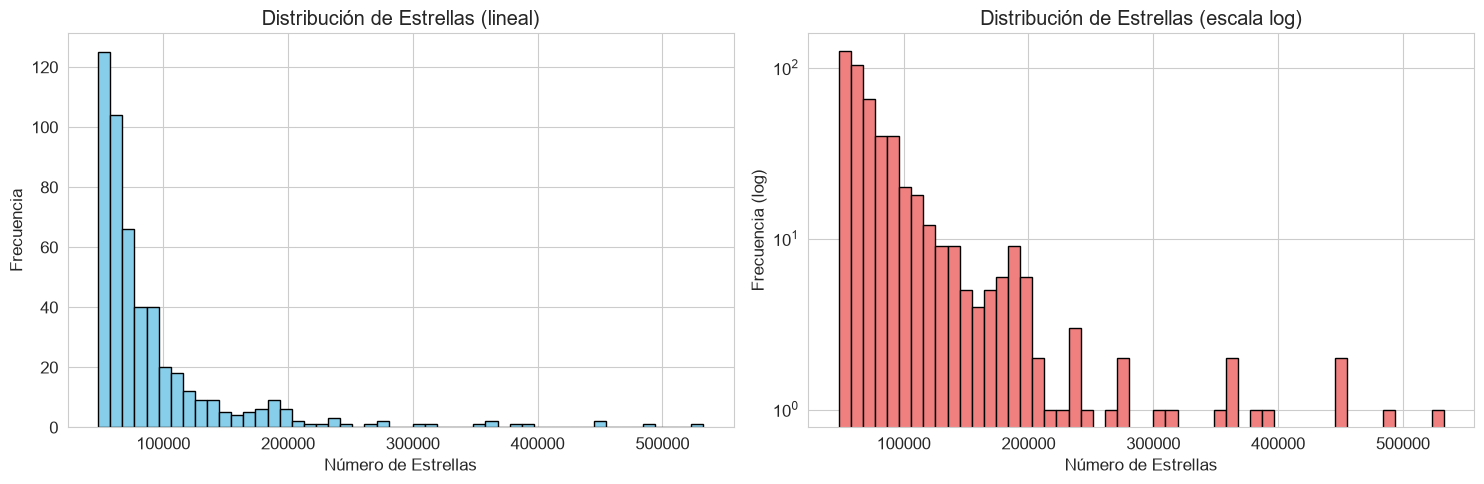

C:\Users\REYES\AppData\Local\Temp\ipykernel_2080\491867806.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='language', y='stargazers_count', palette='viridis')


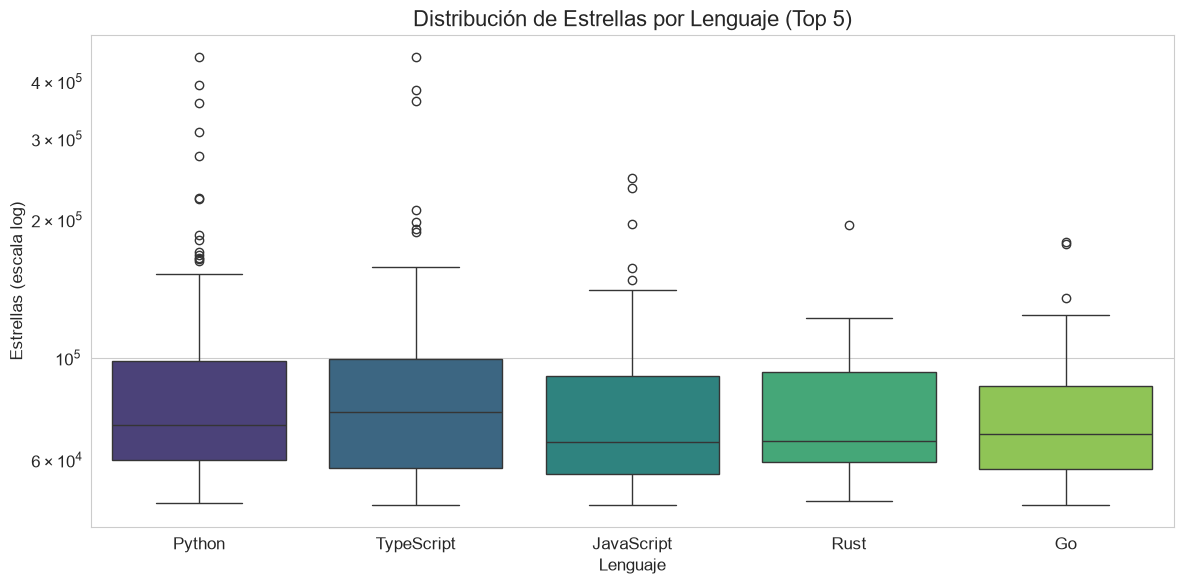

In [12]:
# Distribución de estrellas (histograma con escala log)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma lineal
axes[0].hist(df['stargazers_count'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Estrellas (lineal)')
axes[0].set_xlabel('Número de Estrellas')
axes[0].set_ylabel('Frecuencia')

# Histograma logarítmico
axes[1].hist(df['stargazers_count'], bins=50, color='lightcoral', edgecolor='black', log=True)
axes[1].set_title('Distribución de Estrellas (escala log)')
axes[1].set_xlabel('Número de Estrellas')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

# Boxplot de estrellas por lenguaje (top 5)
top_langs = df['language'].value_counts().head(5).index
df_top = df[df['language'].isin(top_langs)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='language', y='stargazers_count', palette='viridis')
plt.title('Distribución de Estrellas por Lenguaje (Top 5)', fontsize=16)
plt.yscale('log')  # Escala log para mejor visualización
plt.ylabel('Estrellas (escala log)')
plt.xlabel('Lenguaje')
plt.tight_layout()
plt.show()

## 3. Análisis Temporal
- ¿Cómo ha cambiado la popularidad de los lenguajes en el tiempo?
- ¿Cuándo se crearon los repositorios más populares?
- Evolución de estrellas acumuladas.

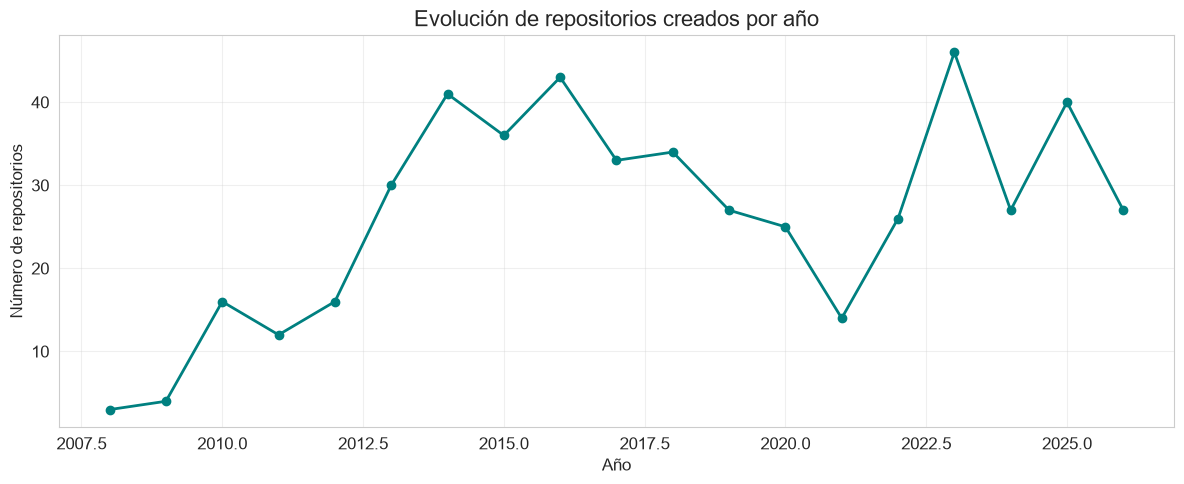

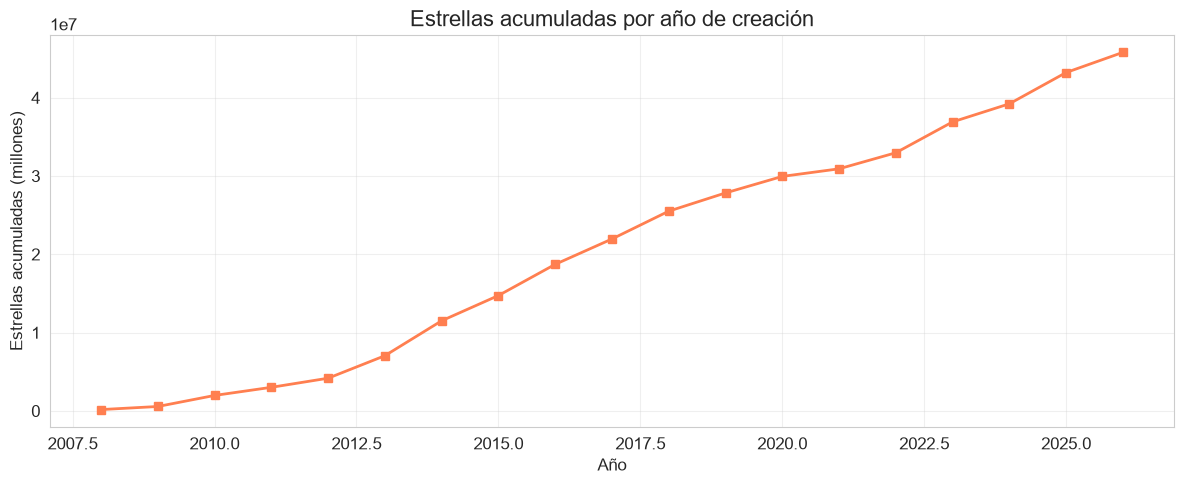

In [13]:
# Crear columna de año de creación
df['year'] = df['created_at'].dt.year

# Evolución de repositorios por año
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
year_counts.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Evolución de repositorios creados por año', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Número de repositorios')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estrellas acumuladas por año (suma acumulativa)
yearly_stars = df.groupby('year')['stargazers_count'].sum().sort_index()
cumulative_stars = yearly_stars.cumsum()

plt.figure(figsize=(12, 5))
cumulative_stars.plot(kind='line', marker='s', color='coral', linewidth=2)
plt.title('Estrellas acumuladas por año de creación', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Estrellas acumuladas (millones)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

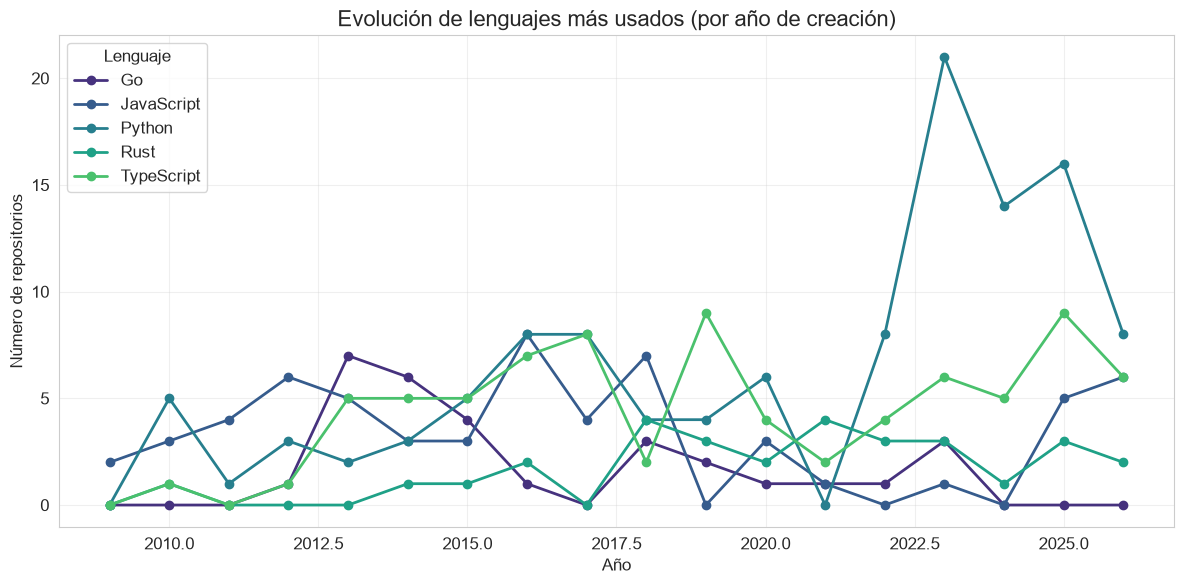

In [14]:
# Tendencias de lenguajes en el tiempo
# Top lenguajes y su evolución
top_langs = df['language'].value_counts().head(5).index
df_lang_year = df[df['language'].isin(top_langs)]
lang_year_counts = df_lang_year.groupby(['year', 'language']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
lang_year_counts.plot(kind='line', marker='o', linewidth=2)
plt.title('Evolución de lenguajes más usados (por año de creación)', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Número de repositorios')
plt.legend(title='Lenguaje')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Análisis de texto: Nube de palabras
Extraemos las palabras más frecuentes en las descripciones de los repositorios para ver qué temas dominan.

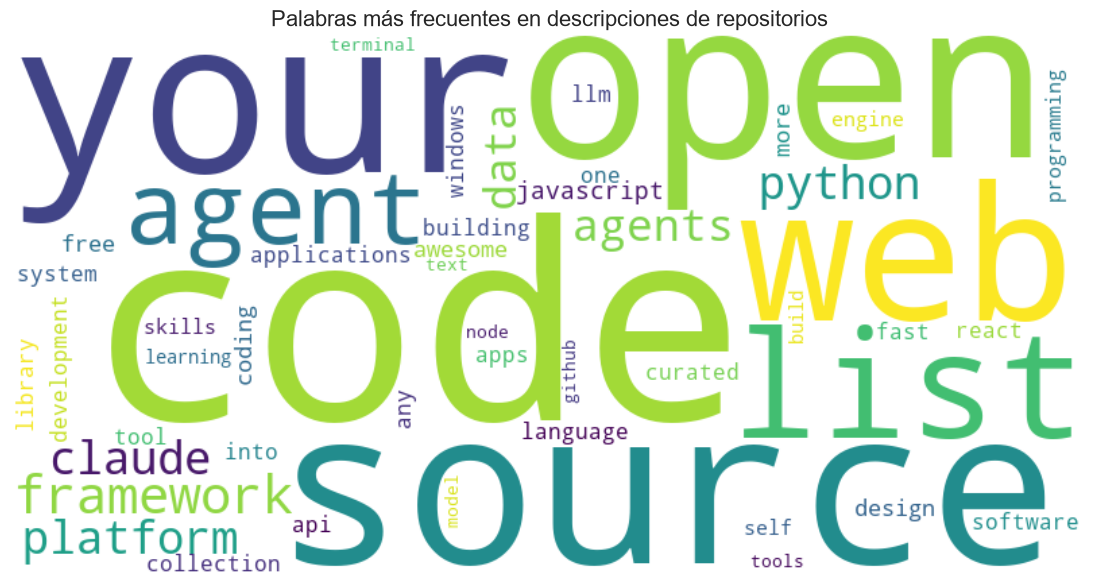

In [16]:

try:
    from wordcloud import WordCloud
    
    # Obtener todas las palabras clave
    all_keywords = []
    for kw_list in df['keywords']:
        all_keywords.extend(kw_list)
    
    # Contar frecuencia
    word_freq = Counter(all_keywords)
    most_common = word_freq.most_common(30)
    
    # Crear nube de palabras
    wordcloud = WordCloud(width=800, height=400, 
                         background_color='white',
                         colormap='viridis',
                         max_words=50).generate_from_frequencies(word_freq)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Palabras más frecuentes en descripciones de repositorios', fontsize=16)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️ WordCloud no instalado. Ejecuta: pip install wordcloud")
    
    # Mostrar top palabras en su lugar
    print("\nTop 20 palabras más frecuentes:")
    for word, count in word_freq.most_common(20):
        print(f"  {word}: {count}")

## 5. Correlaciones entre variables
¿Qué relación hay entre estrellas, forks, issues y tamaño/edad?


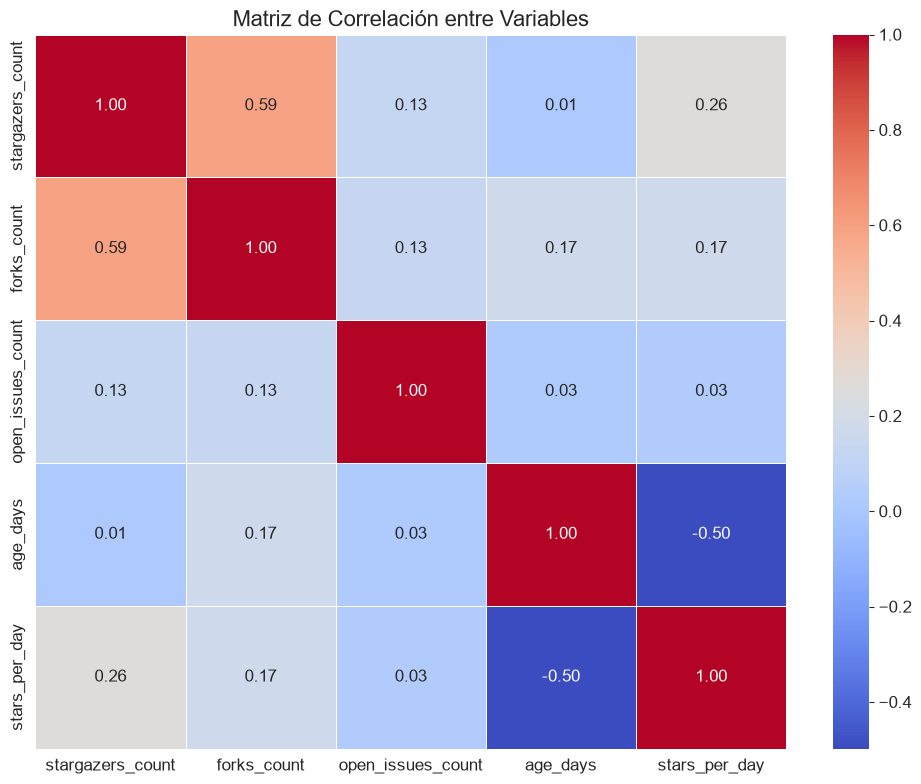

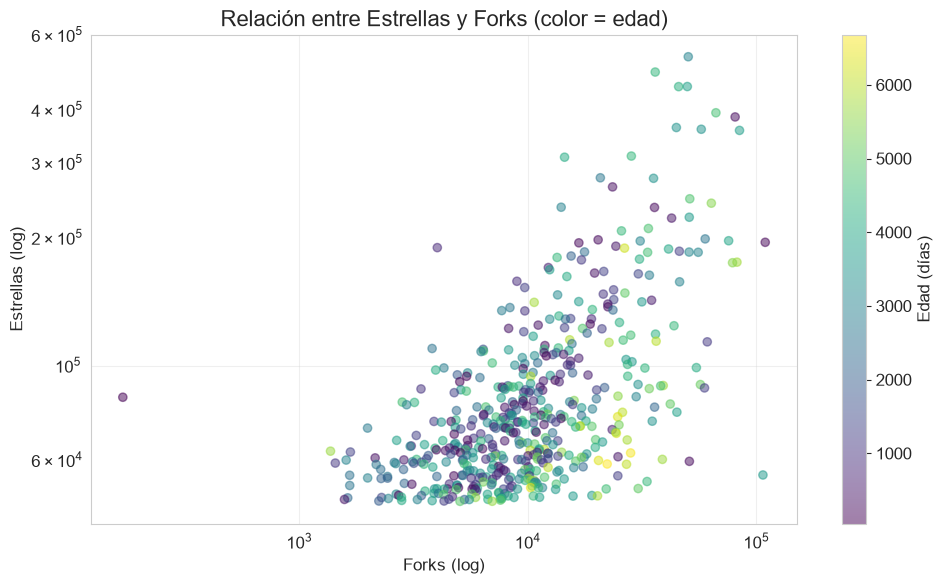

In [18]:
# Seleccionar variables numéricas relevantes
corr_vars = ['stargazers_count', 'forks_count', 'open_issues_count', 'age_days', 'stars_per_day']

# Para 'size' (si existe)
if 'size' in df.columns:
    corr_vars.append('size')

# Crear matriz de correlación
corr_df = df[corr_vars].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación entre Variables', fontsize=16)
plt.tight_layout()
plt.show()

# Scatter plot: Estrellas vs Forks
plt.figure(figsize=(10, 6))
plt.scatter(df['forks_count'], df['stargazers_count'], alpha=0.5, c=df['age_days'], cmap='viridis')
plt.colorbar(label='Edad (días)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Forks (log)')
plt.ylabel('Estrellas (log)')
plt.title('Relación entre Estrellas y Forks (color = edad)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Estadísticas clave
Resumen numérico de los datos más relevantes.

In [19]:
# Estadísticas principales
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"Total de repositorios analizados: {len(df)}")
print(f"Lenguajes distintos: {df['language'].nunique()}")
print(f"Total de estrellas acumuladas: {df['stargazers_count'].sum():,}")
print(f"Total de forks acumulados: {df['forks_count'].sum():,}")
print(f"Promedio de estrellas por repositorio: {df['stargazers_count'].mean():.2f}")
print(f"Mediana de estrellas: {df['stargazers_count'].median():.0f}")
print(f"Máximo de estrellas: {df['stargazers_count'].max()}")
print(f"Repositorio con más estrellas: {df.loc[df['stargazers_count'].idxmax(), 'name']}")

# Repositorios con más estrellas
print("\n=== TOP 5 REPOSITORIOS POR ESTRELLAS ===")
top_repos = df.nlargest(5, 'stargazers_count')[['name', 'language', 'stargazers_count', 'forks_count', 'description']]
for _, row in top_repos.iterrows():
    print(f"📦 {row['name']} ({row['language']})")
    print(f"   ⭐ {row['stargazers_count']:,} estrellas, 🍴 {row['forks_count']:,} forks")
    print(f"   📝 {row['description'][:100] if pd.notna(row['description']) else 'Sin descripción'}...")
    print()

=== ESTADÍSTICAS DESCRIPTIVAS ===
Total de repositorios analizados: 500
Lenguajes distintos: 34
Total de estrellas acumuladas: 45,787,289
Total de forks acumulados: 7,220,228
Promedio de estrellas por repositorio: 91574.58
Mediana de estrellas: 71626
Máximo de estrellas: 532733
Repositorio con más estrellas: build-your-own-x

=== TOP 5 REPOSITORIOS POR ESTRELLAS ===
📦 build-your-own-x (Markdown)
   ⭐ 532,733 estrellas, 🍴 50,387 forks
   📝 Master programming by recreating your favorite technologies from scratch....

📦 awesome (nan)
   ⭐ 490,367 estrellas, 🍴 36,115 forks
   📝 😎 Awesome lists about all kinds of interesting topics...

📦 public-apis (Python)
   ⭐ 453,312 estrellas, 🍴 49,918 forks
   📝 A collective list of free APIs...

📦 freeCodeCamp (TypeScript)
   ⭐ 453,120 estrellas, 🍴 45,729 forks
   📝 freeCodeCamp.org's open-source codebase and curriculum. Learn math, programming, and computer scienc...

📦 free-programming-books (Python)
   ⭐ 393,271 estrellas, 🍴 66,581 forks
   📝 :boo

## 7. Guardar resultados procesados
Para usar en el notebook de conclusiones.

In [21]:
"""# Guardar DataFrame enriquecido para el notebook 3
processed_path = '../data/github_data_processed.json'
df.to_json(processed_path, orient='records', date_format='iso', indent=2)
print(f"✅ Datos procesados guardados en {processed_path}")

# También guardar algunas estadísticas clave
stats = {
    'total_repos': len(df),
    'unique_languages': df['language'].nunique(),
    'total_stars': int(df['stargazers_count'].sum()),
    'total_forks': int(df['forks_count'].sum()),
    'avg_stars': float(df['stargazers_count'].mean()),
    'median_stars': float(df['stargazers_count'].median()),
    'max_stars': int(df['stargazers_count'].max()),
    'top_repo': df.loc[df['stargazers_count'].idxmax(), 'name'],
    'top_language': df['language'].value_counts().index[0],
    'most_common_keywords': [word for word, count in word_freq.most_common(10)]
}

with open('../data/stats_summary.json', 'w', encoding='utf-8') as f:
    json.dump(stats, f, indent=2, ensure_ascii=False)
    
print("✅ Estadísticas guardadas en stats_summary.json")""" 



# Guardar DataFrame enriquecido para el notebook 3 (formato CSV)
processed_csv_path = '../data/github_data_enriched.csv'
df.to_csv(processed_csv_path, index=False, encoding='utf-8')
print(f"✅ Datos procesados guardados en {processed_csv_path}")

# Guardar algunas estadísticas clave (como CSV también, para fácil lectura)
stats_df = pd.DataFrame({
    'Metrica': ['Total repositorios', 'Lenguajes únicos', 'Total estrellas', 'Total forks', 
                'Promedio estrellas', 'Mediana estrellas', 'Máximo estrellas', 'Top repo', 
                'Lenguaje top', 'Top 10 palabras clave'],
    'Valor': [
        len(df),
        df['language'].nunique(),
        int(df['stargazers_count'].sum()),
        int(df['forks_count'].sum()),
        float(df['stargazers_count'].mean()),
        float(df['stargazers_count'].median()),
        int(df['stargazers_count'].max()),
        df.loc[df['stargazers_count'].idxmax(), 'name'],
        df['language'].value_counts().index[0],
        ', '.join([word for word, count in word_freq.most_common(10)])
    ]
})

stats_csv_path = '../data/stats_summary.csv'
stats_df.to_csv(stats_csv_path, index=False, encoding='utf-8')
print(f"✅ Estadísticas guardadas en {stats_csv_path}")

✅ Datos procesados guardados en ../data/github_data_enriched.csv
✅ Estadísticas guardadas en ../data/stats_summary.csv


## Resumen de este notebook

Hemos explorado en profundidad los datos de GitHub:

- **Distribuciones:** Lenguajes, estrellas, forks, etc.
- **Tendencias temporales:** Evolución de repositorios y lenguajes.
- **Correlaciones:** Relaciones entre variables clave.
- **Nube de palabras:** Temas más comunes en descripciones.

El siguiente notebook (`03_Results_and_Conclusions`) sintetizará los hallazgos y extraerá conclusiones finales.